In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, Flatten, MaxPooling2D
from tensorflow.keras.losses import sparse_categorical_crossentropy

model = Sequential()

#1. add a convulational layer (convulational layer adds filters to the image to detect various patterns/features)
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))

#2. add a MaxPooling layer (this layer reduces the feature map size that got created in convulational layer)
model.add(MaxPooling2D())

#3. flatten the output from the maxpooling layer (converts 2D matrix into 1D vector)
model.add(Flatten())

#4. dropout some random neurons to reduce overfitting
model.add(Dropout(0.2))

#5. adding a dense layer of neurons (this finds out complex combinations of features
#eg - sole shape, ankle structure, etc)
model.add(Dense(128, activation='relu'))

#6. final output layer (Dense layer with 10 neurons because fashion_nmist has 10 classes, activation = 'softmax')
model.add(Dense(10, activation = 'softmax'))
"""[
0.01,  # T-shirt
0.00,  # Trouser
0.02,  # Pullover
0.01,  # Dress
0.01,  # Coat
0.03,  # Sandal
0.02,  # Shirt
0.04,  # Sneaker
0.01,  # Bag
0.85   # Ankle boot
]"""

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,771,594 (10.57 MB)

 Trainable params: 2,771,594 (10.57 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 137s 72ms/step - accuracy: 0.8517 - loss: 1.1027
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 145s 74ms/step - accuracy: 0.8937 - loss: 0.2938
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 135s 72ms/step - accuracy: 0.9023 - loss: 0.2697
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 144s 73ms/step - accuracy: 0.9051 - loss: 0.2577
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 139s 74ms/step - accuracy: 0.9131 - loss: 0.2360


In [9]:
loss, accuracy = model.evaluate(x_test, y_test)
print("The loss on testing data is: ", loss)
print("The accuracy on testing data is: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8877 - loss: 0.3209
The loss on testing data is:  0.32085201144218445
The accuracy on testing data is:  0.8877000212669373


In [11]:
import numpy as np
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [13]:
from sklearn.metrics import classification_report
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1000
           1       1.00      0.97      0.98      1000
           2       0.78      0.87      0.82      1000
           3       0.85      0.92      0.88      1000
           4       0.81      0.81      0.81      1000
           5       0.95      0.99      0.97      1000
           6       0.71      0.69      0.70      1000
           7       0.97      0.92      0.94      1000
           8       0.98      0.98      0.98      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



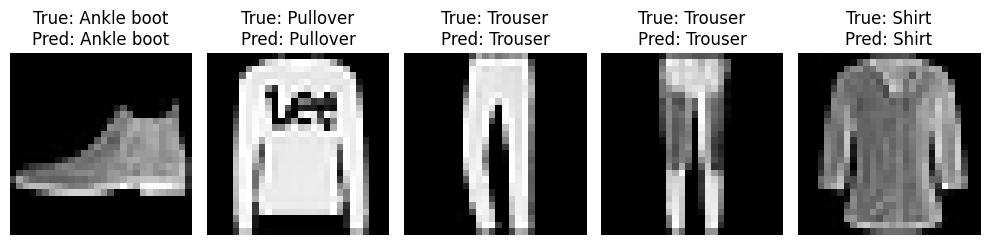

In [15]:
# sample predictions

labels = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {labels[y_test[i]]}\nPred: {labels[y_pred[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()